# Fourier denoising 1D


## Example:

(a) Generate 3 sine waves with frequencies $1\rm Hz$, $5 Hz$, and $8 Hz$, amplitudes $4$, $2$ and $0.25$, and phase all zeros, adding Gaussian noise to them.

(b) Plot this $3$ sine waves together with a sampling rate $100 Hz$.

(c) Calculate the FFT of the resulting signal.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def sine_wave(amp, freq, t):
    # amp  = amplitude
    # freq = frequency
    # t    = time_axis
    
    return amp*np.sin(2*np.pi*freq*t)

In [3]:
# sampling rate
s_rate = 100 #Hz

# sampling interval, signal goes from 0 to 1
s_interval = 1.0/s_rate

# t_axis
t = np.arange(0.,1., s_interval)

# signal amplitudes
amp_1 = 4.
amp_2 = 2.
amp_3 = 0.25

# signal frequencies
freq_1 = 1.
freq_2 = 5.
freq_3 = 8.

# signal
signal = sine_wave(amp_1, freq_1, t) +\
         sine_wave(amp_2, freq_2, t) +\
         sine_wave(amp_3, freq_3, t)

# create copy of the signal
signal_clean = signal.copy()

# add noise to the signal
# https://numpy.org/doc/stable/reference/random/generated/numpy.random.randn.html

signal = signal + 0.20*np.random.randn(len(t))

print(t.size, signal.size)

100 100


### Noisy signal:

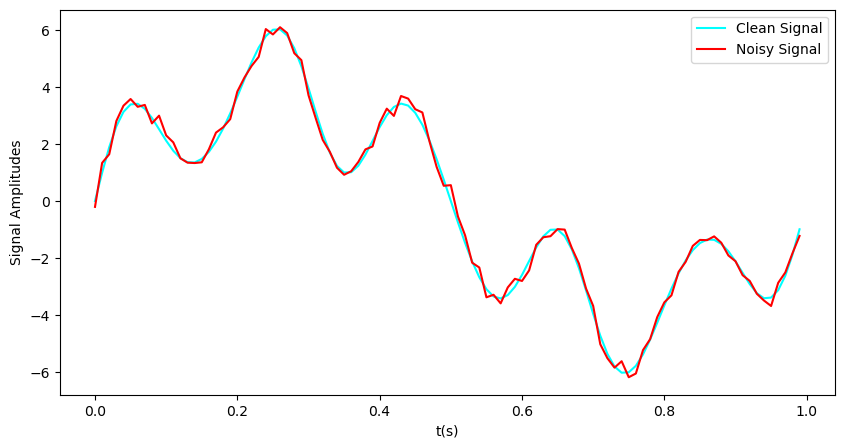

In [4]:
plt.figure(figsize= (10,5))

plt.plot(t, signal_clean, "cyan", label = "Clean Signal")
plt.plot(t, signal, "red", label = "Noisy Signal")

plt.legend()

plt.xlabel("t(s)")
plt.ylabel("Signal Amplitudes")
plt.show()

## Fourier space:

In [5]:
fourier_signal = np.fft.fft(signal)

# Calculate the frequencies manually
N = len(fourier_signal)
n = np.arange(N)
T = N/s_rate
freqs = n/T

#We could've used np.fft.fftfreq(N, d=1/s_rate) to get the frequencies
# but we are doing it manually to understand the concept

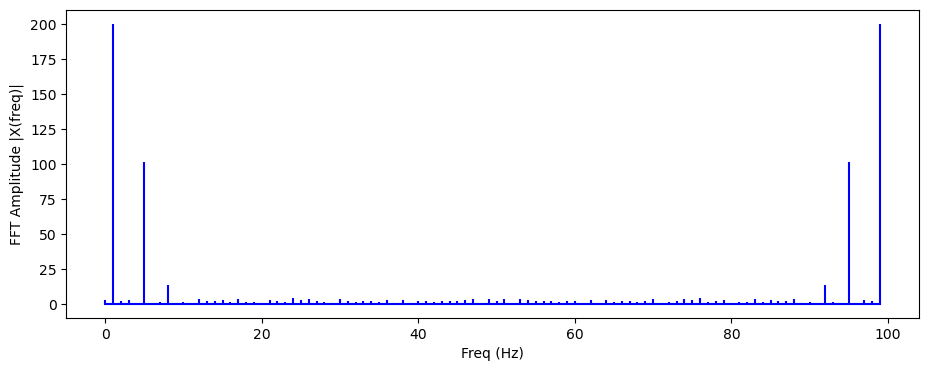

In [6]:
plt.figure(figsize = (11, 4))
plt.stem(freqs, np.abs(fourier_signal), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.show()

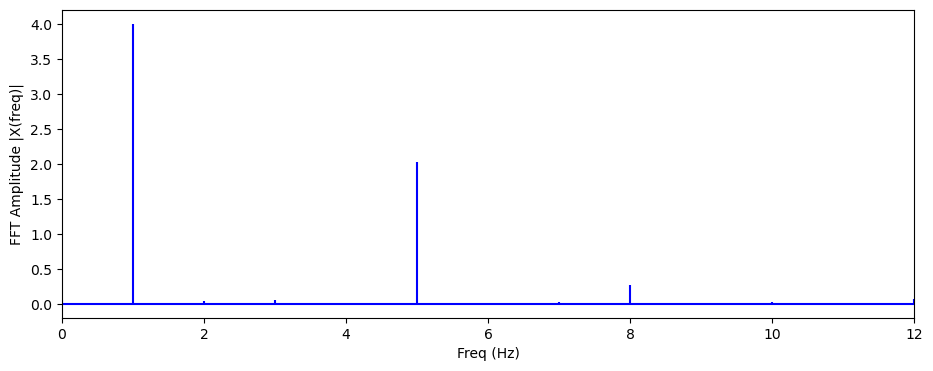

In [7]:
plt.figure(figsize = (11, 4))
plt.stem(freqs[:N//2], abs(fourier_signal)[:N//2]/(N//2), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')

plt.xlim(0,12)
plt.show()

Noise is populating everything. 

When we increase the amplitude of noise, we may lose differentiability on low amplitude frequencies.

## Remove noise based on a amplitude threshold

In [8]:
# Amplitude thresh0ld

amp_threshold = 8 #this threshold value is based on the unnormalized frequencies plot

indices = np.abs(fourier_signal) > amp_threshold

print(indices.shape)

(100,)


### Cleaned signal:

In [9]:
fourier_signal_2 = indices*fourier_signal

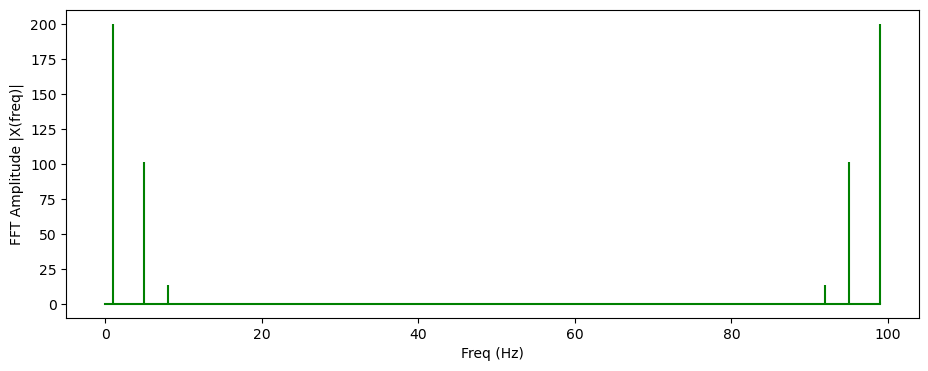

In [10]:
plt.figure(figsize = (11,4))
#plt.stem(freqs, np.abs(fourier_signal), 'b', markerfmt=" ", basefmt="-b")
plt.stem(freqs, np.abs(fourier_signal_2), 'g', markerfmt=" ", basefmt="-g")
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.show()

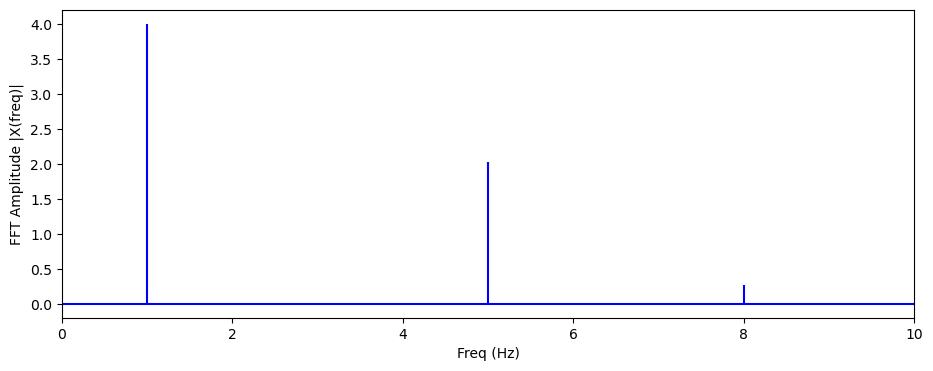

In [11]:
plt.figure(figsize = (11, 4))
plt.stem(freqs[:N//2], abs(fourier_signal_2)[:N//2]/(N//2), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')

plt.xlim(0,10)
plt.show()

## Inverse Fourier Transform of the filtered Fourier signal

In [12]:
signal_filtered = np.fft.ifft(fourier_signal_2)

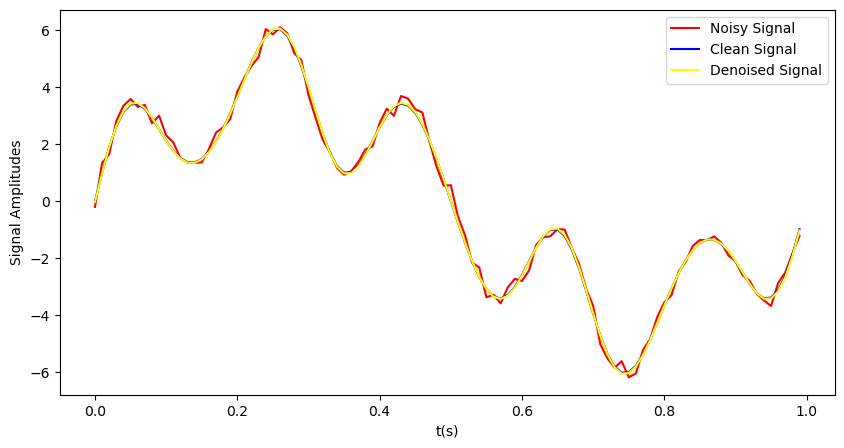

In [13]:
plt.figure(figsize= (10,5))

plt.plot(t, signal, "red", label = "Noisy Signal")
plt.plot(t, signal_clean, "blue", label = "Clean Signal")
plt.plot(t, signal_filtered.real, "yellow", label = "Denoised Signal")

plt.xlabel("t(s)")
plt.ylabel("Signal Amplitudes")
plt.legend()
plt.show()